# Wikipedia XML Dump EDA

Exploring the raw MediaWiki export files in `../raw_data/`. Each `.xml.bz2` has
already been decompressed into a sibling folder containing a single `.xml` file
(10GB+ each), so all reads here are **streamed** rather than loaded into memory.

In [1]:
from pathlib import Path
import xml.etree.ElementTree as ET

import pandas as pd
import matplotlib.pyplot as plt

RAW_DATA_DIR = Path("../raw_data")

## 1. Locate the dump shards

Each shard is a folder named after the file, containing the decompressed `.xml`
plus the original `.xml.bz2` sits alongside it.

In [2]:
xml_files = sorted(RAW_DATA_DIR.glob("*/*.xml"))

files_df = pd.DataFrame(
    [{"file": f.name, "size_gb": f.stat().st_size / 1e9} for f in xml_files]
)
print(f"{len(xml_files)} decompressed shards, {files_df['size_gb'].sum():.1f} GB total")
files_df

19 decompressed shards, 228.3 GB total


,file,size_gb
0,enwiki-2026-07-01-p10p1400054.xml,10.635128
1,enwiki-2026-07-01-p1400055p4535457.xml,11.285903
2,enwiki-2026-07-01-p14370076p20092818.xml,13.063092
3,enwiki-2026-07-01-p20092820p25200123.xml,12.884679
4,enwiki-2026-07-01-p25200124p30665211.xml,13.185486
5,enwiki-2026-07-01-p30665212p35562460.xml,12.811042
6,enwiki-2026-07-01-p35562462p40740324.xml,13.076923
7,enwiki-2026-07-01-p40740325p45501698.xml,12.862257
8,enwiki-2026-07-01-p4535458p9093924.xml,11.951140
9,enwiki-2026-07-01-p45501699p50570415.xml,13.127814


## 2. Peek at the raw text

Read the first few thousand lines of a shard line-by-line (no full-file load) to
get a feel for the raw formatting before we bother parsing it as XML.

In [3]:
def peek_lines(path, n_lines=2000):
    """Stream the first n_lines of a (potentially huge) text file."""
    lines = []
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        for i, line in enumerate(f):
            if i >= n_lines:
                break
            lines.append(line.rstrip("\n"))
    return lines


sample_file = xml_files[0]
first_lines = peek_lines(sample_file, n_lines=2000)
print(f"--- first {len(first_lines)} lines of {sample_file.name} ---\n")
print("\n".join(first_lines))

--- first 2000 lines of enwiki-2026-07-01-p10p1400054.xml ---

<mediawiki xmlns="http://www.mediawiki.org/xml/export-0.11/" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:schemaLocation="http://www.mediawiki.org/xml/export-0.11/ http://www.mediawiki.org/xml/export-0.11.xsd" version="0.11" xml:lang="en">
  <siteinfo>
    <sitename>Wikipedia</sitename>
    <dbname>enwiki</dbname>
    <base>https://en.wikipedia.org/wiki/Main_Page</base>
    <generator>MediaWiki Content File Export 0.3.12</generator>
    <case>first-letter</case>
    <namespaces>
      <namespace key="-2" case="first-letter">Media</namespace>
      <namespace key="-1" case="first-letter">Special</namespace>
      <namespace key="0" case="first-letter" />
      <namespace key="1" case="first-letter">Talk</namespace>
      <namespace key="2" case="first-letter">User</namespace>
      <namespace key="3" case="first-letter">User talk</namespace>
      <namespace key="4" case="first-letter">Wikipedia</namespace>
    

## 3. XML structure: `<siteinfo>` and namespaces

These are standard [MediaWiki XML export](https://www.mediawiki.org/xml/export-0.11)
dumps: a `<mediawiki>` root, a `<siteinfo>` header describing the wiki and its
namespaces, then a stream of `<page>` elements. `ET.iterparse` lets us read this
incrementally and stop as soon as `<siteinfo>` closes, instead of parsing 10GB.

In [4]:
def strip_ns(tag):
    """'{http://.../export-0.11/}page' -> 'page'"""
    return tag.split("}", 1)[-1] if "}" in tag else tag


def get_siteinfo(path):
    info = {"namespaces": []}
    for _event, elem in ET.iterparse(path, events=("end",)):
        tag = strip_ns(elem.tag)
        if tag == "namespace":
            info["namespaces"].append({"key": elem.get("key"), "name": elem.text})
        elif tag in ("sitename", "dbname", "generator", "case"):
            info[tag] = elem.text
        elif tag == "siteinfo":
            elem.clear()
            break
        elem.clear()
    return info


siteinfo = get_siteinfo(sample_file)
print({k: v for k, v in siteinfo.items() if k != "namespaces"})
pd.DataFrame(siteinfo["namespaces"])

{'sitename': 'Wikipedia', 'dbname': 'enwiki', 'generator': 'MediaWiki Content File Export 0.3.12', 'case': 'first-letter'}


,key,name
0,-2,Media
1,-1,Special
2,0,NaN
3,1,Talk
4,2,User
5,3,User talk
6,4,Wikipedia
7,5,Wikipedia talk
8,6,File
9,7,File talk


## 4. Sample `<page>` elements via streaming parse

Each `<page>` holds a `<title>`, `<ns>`, `<id>`, an optional `<redirect>`, and one
or more `<revision>` blocks with the actual wikitext. We stream with
`iterparse`, pull out the fields we care about, and `elem.clear()` each page once
we're done with it so memory stays flat — this lets us sample thousands of pages
from a 10GB file in seconds instead of parsing the whole thing.

In [5]:
def iter_pages(path, max_pages=None):
    """Stream <page> elements from a MediaWiki export XML file as flat dicts."""
    count = 0
    for _event, elem in ET.iterparse(path, events=("end",)):
        if strip_ns(elem.tag) != "page":
            continue

        children = {strip_ns(c.tag): c for c in elem}
        redirect_el = children.get("redirect")
        revision_el = children.get("revision")

        page = {
            "title": children["title"].text if "title" in children else None,
            "ns": children["ns"].text if "ns" in children else None,
            "id": children["id"].text if "id" in children else None,
            "is_redirect": redirect_el is not None,
            "redirect_target": redirect_el.get("title") if redirect_el is not None else None,
            "revision_id": None,
            "timestamp": None,
            "contributor_username": None,
            "text_bytes": None,
            "text_len_chars": None,
        }

        if revision_el is not None:
            rev_children = {strip_ns(c.tag): c for c in revision_el}
            page["revision_id"] = rev_children["id"].text if "id" in rev_children else None
            page["timestamp"] = rev_children["timestamp"].text if "timestamp" in rev_children else None

            contributor_el = rev_children.get("contributor")
            if contributor_el is not None:
                contrib_children = {strip_ns(c.tag): c for c in contributor_el}
                page["contributor_username"] = (
                    contrib_children["username"].text if "username" in contrib_children else None
                )

            text_el = rev_children.get("text")
            if text_el is not None:
                page["text_bytes"] = int(text_el.get("bytes")) if text_el.get("bytes") else None
                page["text_len_chars"] = len(text_el.text) if text_el.text else 0

        yield page

        elem.clear()
        count += 1
        if max_pages is not None and count >= max_pages:
            break

In [6]:
%%time
sample_pages = list(iter_pages(sample_file, max_pages=2000))

pages_df = pd.DataFrame(sample_pages)
pages_df["ns"] = pages_df["ns"].astype(int)
pages_df["id"] = pages_df["id"].astype(int)
pages_df["timestamp"] = pd.to_datetime(pages_df["timestamp"])

print(pages_df.shape)
pages_df.head()

(2000, 10)
CPU times: total: 203 ms
Wall time: 224 ms


,title,ns,id,is_redirect,redirect_target,revision_id,timestamp,contributor_username,text_bytes,text_len_chars
0,AccessibleComputing,0,10,True,Computer accessibility,1219062925,2024-04-15 14:38:04+00:00,Asparagusus,111,111
1,AfghanistanHistory,0,13,True,History of Afghanistan,783865149,2017-06-05 04:18:18+00:00,Tom.Reding,90,90
2,AfghanistanGeography,0,14,True,Geography of Afghanistan,783865160,2017-06-05 04:18:23+00:00,Tom.Reding,92,92
3,AfghanistanPeople,0,15,True,Demographics of Afghanistan,783865293,2017-06-05 04:19:42+00:00,Tom.Reding,95,95
4,AfghanistanCommunications,0,18,True,Communications in Afghanistan,783865299,2017-06-05 04:19:45+00:00,Tom.Reding,97,97


## 5. EDA on the sample

In [7]:
pages_df.info()
pages_df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   title                 2000 non-null   str                
 1   ns                    2000 non-null   int64              
 2   id                    2000 non-null   int64              
 3   is_redirect           2000 non-null   bool               
 4   redirect_target       537 non-null    str                
 5   revision_id           2000 non-null   str                
 6   timestamp             2000 non-null   datetime64[us, UTC]
 7   contributor_username  1984 non-null   str                
 8   text_bytes            2000 non-null   int64              
 9   text_len_chars        2000 non-null   int64              
dtypes: bool(1), datetime64[us, UTC](1), int64(4), str(4)
memory usage: 142.7 KB


,title,ns,id,is_redirect,redirect_target,revision_id,timestamp,contributor_username,text_bytes,text_len_chars
count,2000,2000.000000,2000.00000,2000,537,2000,2000,1984,2000.000000,2000.000000
unique,2000,NaN,NaN,2,435,2000,NaN,1055,NaN,NaN
top,AccessibleComputing,NaN,NaN,False,Automated Alice,1219062925,NaN,Tom.Reding,NaN,NaN
freq,1,NaN,NaN,1463,12,1,NaN,199,NaN,NaN
mean,NaN,0.115000,1973.02350,NaN,NaN,NaN,2024-02-19 22:12:43.257500+00:00,NaN,30925.246000,30810.905000
min,NaN,0.000000,10.00000,NaN,NaN,NaN,2002-04-06 14:14:34+00:00,NaN,19.000000,19.000000
25%,NaN,0.000000,1284.75000,NaN,NaN,NaN,2024-10-22 14:27:52.250000+00:00,NaN,137.000000,137.000000
50%,NaN,0.000000,1977.00000,NaN,NaN,NaN,2026-04-28 17:12:42+00:00,NaN,12297.000000,12235.500000
75%,NaN,0.000000,2713.25000,NaN,NaN,NaN,2026-06-16 21:41:17+00:00,NaN,42442.000000,42227.000000
max,NaN,5.000000,3522.00000,NaN,NaN,NaN,2026-06-30 23:47:19+00:00,NaN,339089.000000,338350.000000


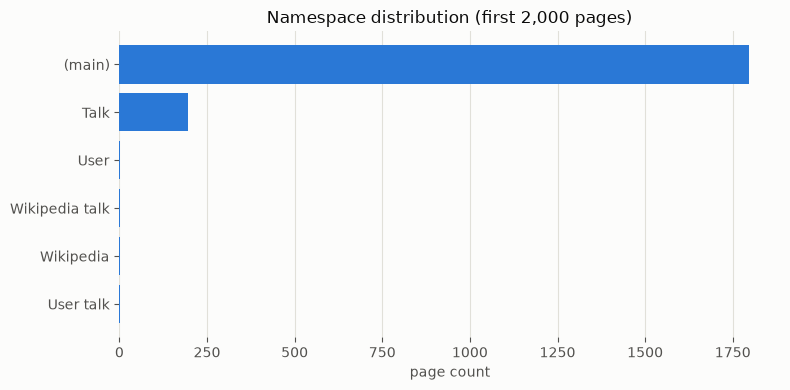

In [8]:
ns_names = {int(n["key"]): n["name"] or "(main)" for n in siteinfo["namespaces"]}
ns_counts = pages_df["ns"].value_counts().rename(index=ns_names)

fig, ax = plt.subplots(figsize=(8, 4), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
ax.barh(ns_counts.index[::-1], ns_counts.values[::-1], color="#2a78d6")
ax.set_xlabel("page count", color="#52514e")
ax.set_title(f"Namespace distribution (first {len(pages_df):,} pages)", color="#0b0b0b")
ax.tick_params(colors="#52514e")
ax.grid(axis="x", color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

In [9]:
redirect_share = pages_df["is_redirect"].mean()
print(f"{redirect_share:.1%} of sampled pages are redirects")
pages_df.loc[pages_df["is_redirect"], ["title", "redirect_target"]].head(10)

26.9% of sampled pages are redirects


,title,redirect_target
0,AccessibleComputing,Computer accessibility
1,AfghanistanHistory,History of Afghanistan
2,AfghanistanGeography,Geography of Afghanistan
3,AfghanistanPeople,Demographics of Afghanistan
4,AfghanistanCommunications,Communications in Afghanistan
5,AfghanistanTransportations,Transport in Afghanistan
6,AfghanistanMilitary,Afghan Armed Forces
7,AfghanistanTransnationalIssues,Foreign relations of Afghanistan
8,AssistiveTechnology,Assistive technology
9,AmoeboidTaxa,Amoeba


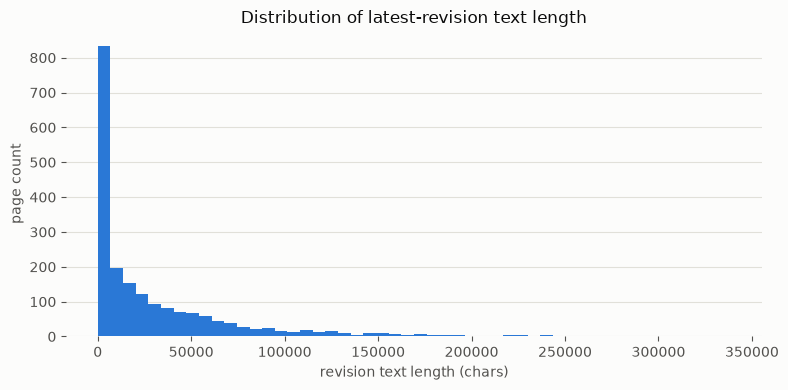

count      2000.000000
mean      30810.905000
std       45976.801579
min          19.000000
25%         137.000000
50%       12235.500000
75%       42227.000000
max      338350.000000
Name: text_len_chars, dtype: float64

In [10]:
fig, ax = plt.subplots(figsize=(8, 4), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
ax.hist(pages_df["text_len_chars"].dropna(), bins=50, color="#2a78d6")
ax.set_xlabel("revision text length (chars)", color="#52514e")
ax.set_ylabel("page count", color="#52514e")
ax.set_title("Distribution of latest-revision text length", color="#0b0b0b")
ax.tick_params(colors="#52514e")
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

pages_df["text_len_chars"].describe()

In [11]:
pages_df["contributor_username"].value_counts().head(15)

contributor_username
Tom.Reding            199
Graham87               67
Zackmann08             41
CitationCleanerBot     26
BD2412                 26
1234qwer1234qwer4      25
Oklopfer               21
Hydrogenation          20
JJMC89 bot III         18
Xqbot                  17
EmausBot               15
Cewbot                 15
SchlurcherBot          14
Bkonrad                13
OAbot                  13
Name: count, dtype: int64

## Next steps

- Bump `max_pages` (or set it to `None`) to sample more/all pages once the shape
  looks right — `iter_pages` stays memory-flat either way.
- Loop `iter_pages` over all of `xml_files` to compare shards, or to build the
  full graph dataset (e.g. redirect edges, page → linked-page structure once we
  parse `[[wikilinks]]` out of `text`).
- `<page>` can contain multiple `<revision>` blocks for dumps with history; this
  parser currently only keeps the first one seen per page — worth checking
  whether these particular shards are current-only or full-history.